# **Random Forest Model**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn import preprocessing
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import classification_report as cl_rep_skl
from imblearn.pipeline import Pipeline,make_pipeline
from imblearn.over_sampling import SMOTE,BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler
from yellowbrick.classifier import confusion_matrix, classification_report, ROCAUC
from yellowbrick.model_selection import CVScores
plt.style.use('ggplot')
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 100)

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [ ]:
def show_values(axs, orient="v", space=.01):
		_single(axs)

def std_num_cols(df):

	# Creating a scalar object

	scaler = StandardScaler()

	# Standardizind the dataframe

	df = scaler.fit_transform(df)

def rb_scale_cols(df):

	# Creating a scalar object

	scaler = RobustScaler()

	# Standardizind the dataframe

	df = scaler.fit_transform(df)

def get_confusion_matrix(bi_clf, X, y, thres=0.5):

	return confusion_matrix(
		y,
		bi_clf.predict_proba(X)[:,1] > thres
	)

def model_results(X_train, y_train, X_test, y_test, model, show = True):

	model.fit(X_train, y_train)

	train_accr = model.score(X_train, y_train)
	test_accr = model.score(X_test, y_test)
	y_pred = model.predict(X_test)
	precision = precision_score(y_test, y_pred)
	avg_precision = average_precision_score(y_test, y_pred)
	recall = recall_score(y_test, y_pred)
	f1 = f1_score(y_test, y_pred)
	roc_auc = roc_auc_score(y_test, y_pred)
	tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
	corr_cls = tp+tn
	incorr_cls = fp+fn

	if show:
		print('The Model Results for ', model)
		print("*"*60)
		print('Train Accuracy is equal to %.3f' %round(train_accr,3))
		print('Test Accuracy is equal to %.3f' %round(test_accr,3))
		print('The Precision score is %.3f' %round(precision,3))
		print('The Average Precision score is %.3f' %round(avg_precision,3))
		print('The Recall score is %.3f' %round(recall,3))
		print('The F1 score is %.3f' %round(f1,3))
		print('The AUC/ROC score is %.3f' %round(roc_auc,3))
		print("True-Positive: %.3f" %tp)
		print("True-Negative: %.3f" %tn)
		print("False-Positive: %.3f" %fp)
		print("False-Negative: %.3f" %fn)
		print("Correctly Classified: %.3f" %corr_cls)
		print("Incorrectly Classified: %.3f" %incorr_cls)

	return [train_accr, test_accr, precision, recall]

### # Loading datasets, and looking at shapes:-

In [ ]:
# Loading train-test 70:30 split (SMOTE and BorderlineSMOTE) datasets
# For these same columns have been drooped as done for the LGR model

trainX_SM = pd.read_csv("trainX_SM.csv",index_col=0)
trainY_SM = pd.read_csv("trainY_SM.csv",index_col=0)
testX_SM = pd.read_csv("testX_SM.csv",index_col=0)
testY_SM = pd.read_csv("testY_SM.csv",index_col=0)

trainX_BSM = pd.read_csv("trainX_BSM.csv",index_col=0)
trainY_BSM = pd.read_csv("trainY_BSM.csv",index_col=0)
testX_BSM = pd.read_csv("testX_BSM.csv",index_col=0)
testY_BSM = pd.read_csv("testY_BSM.csv",index_col=0)

# Looking at dataset shapes

print('\n')
print('Shape of SMOTE balanced trainX data :',trainX_SM.shape)
print('Shape of SMOTE balanced trainY data :',trainY_SM.shape)
print('Shape of SMOTE balanced testX data :',testX_SM.shape)
print('Shape of SMOTE balanced testY data :',testY_SM.shape)
print('Shape of Borderline SMOTE balanced trainX data :',trainX_BSM.shape)
print('Shape of Borderline SMOTE balanced trainY data :',trainY_BSM.shape)
print('Shape of Borderline SMOTE balanced testX data :',testX_BSM.shape)
print('Shape of Borderline SMOTE balanced testY data :',testY_BSM.shape, end='\n')
print('\n')
print("*"*60)

# Looking at class ratios

print('\n')
print('Class ratio - Fraud/Non-Fraud (trainY_SM) :',trainY_SM.value_counts(normalize=True)*100)
print('Class ratio - Fraud/Non-Fraud (testY_SM) :',testY_SM.value_counts(normalize=True)*100)
print('Class ratio - Fraud/Non-Fraud (trainY_BSM) :',trainY_BSM.value_counts(normalize=True)*100)
print('Class ratio - Fraud/Non-Fraud (testY_BSM) :',testY_BSM.value_counts(normalize=True)*100, end='\n')
print('\n')
print("*"*60)



Shape of SMOTE balanced trainX data : (483580, 44)
Shape of SMOTE balanced trainY data : (483580, 1)
Shape of SMOTE balanced testX data : (207250, 44)
Shape of SMOTE balanced testY data : (207250, 1)
Shape of Borderline SMOTE balanced trainX data : (483580, 44)
Shape of Borderline SMOTE balanced trainY data : (483580, 1)
Shape of Borderline SMOTE balanced testX data : (207250, 44)
Shape of Borderline SMOTE balanced testY data : (207250, 1)


************************************************************


Class ratio - Fraud/Non-Fraud (trainY_SM) : PotentialFraud
0                 50.0
1                 50.0
dtype: float64
Class ratio - Fraud/Non-Fraud (testY_SM) : PotentialFraud
0                 50.0
1                 50.0
dtype: float64
Class ratio - Fraud/Non-Fraud (trainY_BSM) : PotentialFraud
0                 50.0
1                 50.0
dtype: float64
Class ratio - Fraud/Non-Fraud (testY_BSM) : PotentialFraud
0                 50.0
1                 50.0
dtype: float64


*******

### # Standardizing the train/test features for balanced datasets:

In [ ]:
# SMOTE balanced dataset

# std_num_cols(trainX_SM)
# std_num_cols(testX_SM)

# BorderlineSMOTE balanced dataset

# std_num_cols(trainX_BSM)
# std_num_cols(testX_BSM)

### Baseline Random Forest Model - Standardized

In [ ]:
# SMOTE Balanced

# rf_std = RandomForestClassifier(random_state=0, oob_score=True)
# model_results(trainX_SM, trainY_SM, testX_SM, testY_SM, rf_std, show = True)

# Out of bag error:

# rf_std.oob_score_

In [ ]:
# BorderlineSMOTE Balanced

# rf_std = RandomForestClassifier(random_state=0, oob_score=True)
# model_results(trainX_BSM, trainY_BSM, testX_BSM, testY_BSM, rf_std, show = True)

# Out of bag error:

# rf_std.oob_score_

### # Robust Scaling the train/test features for  balanced datasets:

In [ ]:
# SMOTE balanced dataset

rb_scale_cols(trainX_SM)
rb_scale_cols(testX_SM)

# BorderlineSMOTE balanced dataset

rb_scale_cols(trainX_BSM)
rb_scale_cols(testX_BSM)

### Baseline Random Forest Model - Robust Scaled

In [ ]:
# SMOTE Balanced

# rf_rb = RandomForestClassifier(random_state=0, oob_score=True)
# model_results(trainX_SM, trainY_SM, testX_SM, testY_SM, rf_rb,show = True)

# Out of bag error:

# rf_rb.oob_score_

In [ ]:
# BorderlineSMOTE Balanced

# rf_rb = RandomForestClassifier(random_state=0, oob_score=True)
# model_results(trainX_BSM, trainY_BSM, testX_BSM, testY_BSM, rf_rb, show = True)

In [ ]:
# Out of bag error:

# rf_rb.oob_score_

- Scaling and different upsampling types does not make much difference, so we will go with datasets with BorderlineSmote upsampling and preprocessed using robust scaler as the first base model.

In [ ]:
# Visualizing the confusion matrix with Yellowbricks (thres=0.5)

# plt.figure(figsize = (10,10))
# confusion_matrix(
#     rf_rb,
#     trainX_BSM, trainY_BSM, testX_BSM, testY_BSM,
#     classes=['Non-Fraud', 'Possibly-Fraud'])

In [ ]:
# Visualizing the AUC/ROC curve with Yellowbricks

# plt.figure(figsize = (14,12))
# sns.set_style("whitegrid")

# visualizer = ROCAUC(rf_rb, classes=['Non-Fraud', 'Possibly-Fraud'])

# visualizer.fit(trainX_BSM, trainY_BSM)        # Fit the training data to the visualizer
# visualizer.score(testX_BSM, testY_BSM)        # Evaluate the model on the test data
# visualizer.show()                           # Finalize and render the figure

In [ ]:
# Visualizing the classification report with Yellowbricks

# plt.figure(figsize = (12,6))
# sns.set_style("whitegrid")

# visualizer = classification_report(
#     rf_rb,
#     trainX_SM, trainY_SM, testX_SM, testY_SM,
#     classes=['Non-Fraud', 'Possibly-Fraud'],
#     cmap='YlGnBu',
#     support=True)

### # Plotting scores for different number of trees in the random forest (BSM):

In [ ]:
# trees_range = range(80, 180, 20)
# train_error = []
# test_error = []
# oob_error = []
# train_AUC = []
# test_AUC = []
# train_F1 = []
# test_F1 = []

# for n_trees in trees_range:
#     rf = RandomForestClassifier(random_state=0, oob_score=True)
#     rf.set_params(n_estimators=n_trees)
#     rf.fit(trainX_BSM, trainY_BSM)
#     train_error.append(1 - rf.score(trainX_BSM, trainY_BSM))
#     test_error.append(1 - rf.score(testX_BSM, testY_BSM))
#     oob_error.append(1 - rf.oob_score_)
#     train_AUC.append(roc_auc_score(trainY_BSM, rf.predict(trainX_BSM)))
#     test_AUC.append(roc_auc_score(testY_BSM, rf.predict(testX_BSM)))
#     train_F1.append(f1_score(trainY_BSM, rf.predict(trainX_BSM)))
#     test_F1.append(f1_score(testY_BSM, rf.predict(testX_BSM)))

In [ ]:
# plt.plot(trees_range, train_error, c='red', label='Training Error')
# plt.plot(trees_range, test_error, c='blue', label='Test Error')
# plt.plot(trees_range, oob_error, c='green', label='OOB Error')
# plt.ylabel('Errors')
# plt.xlabel('Number of trees')
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(trees_range, train_AUC, c='red', label='Training AUC Score')
# plt.plot(trees_range, test_AUC, c='blue', label='Test AUC Score')
# plt.ylabel('AUC Scores')
# plt.xlabel('Number of trees')
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(trees_range, train_F1, c='red', label='Training F1 Score')
# plt.plot(trees_range, test_F1, c='blue', label='Test F1 Score')
# plt.ylabel('F1 Scores')
# plt.xlabel('Number of trees')
# plt.legend()
# plt.show()

### # Plotting scores for different number of trees in the random forest (SM):

In [ ]:
# trees_range = range(80, 180, 10)
# train_error = []
# test_error = []
# oob_error = []
# train_AUC = []
# test_AUC = []
# train_F1 = []
# test_F1 = []

# for n_trees in trees_range:
#     rf = RandomForestClassifier(random_state=0, oob_score=True)
#     rf.set_params(n_estimators=n_trees)
#     rf.fit(trainX_SM, trainY_SM)
#     train_error.append(1 - rf.score(trainX_SM, trainY_SM))
#     test_error.append(1 - rf.score(testX_SM, testY_SM))
#     oob_error.append(1 - rf.oob_score_)
#     train_AUC.append(roc_auc_score(trainY_SM, rf.predict(trainX_SM)))
#     test_AUC.append(roc_auc_score(testY_SM, rf.predict(testX_SM)))
#     train_F1.append(f1_score(trainY_SM, rf.predict(trainX_SM)))
#     test_F1.append(f1_score(testY_SM, rf.predict(testX_SM)))

In [ ]:
# plt.plot(trees_range, train_error, c='red', label='Training Error')
# plt.plot(trees_range, test_error, c='blue', label='Test Error')
# plt.plot(trees_range, oob_error, c='green', label='OOB Error')
# plt.ylabel('Errors')
# plt.xlabel('Number of trees')
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(trees_range, train_AUC, c='red', label='Training AUC Score')
# plt.plot(trees_range, test_AUC, c='blue', label='Test AUC Score')
# plt.ylabel('AUC Scores')
# plt.xlabel('Number of trees')
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(trees_range, train_F1, c='red', label='Training F1 Score')
# plt.plot(trees_range, test_F1, c='blue', label='Test F1 Score')
# plt.ylabel('F1 Scores')
# plt.xlabel('Number of trees')
# plt.legend()
# plt.show()

### # Plotting scores for different tree depths in the random forest:

In [ ]:
# depth_range = range(5, 20, 5)
# train_error = []
# test_error = []
# oob_error = []
# train_AUC = []
# test_AUC = []
# train_F1 = []
# test_F1 = []

# for max_depth in depth_range:
#     rf = RandomForestClassifier(random_state=0, oob_score=True)
#     rf.set_params(max_depth=max_depth)
#     rf.fit(trainX_BSM, trainY_BSM)
#     train_error.append(1 - rf.score(trainX_BSM, trainY_BSM))
#     test_error.append(1 - rf.score(testX_BSM, testY_BSM))
#     oob_error.append(1 - rf.oob_score_)
#     train_AUC.append(roc_auc_score(trainY_BSM, rf.predict(trainX_BSM)))
#     test_AUC.append(roc_auc_score(testY_BSM, rf.predict(testX_BSM)))
#     train_F1.append(f1_score(trainY_BSM, rf.predict(trainX_BSM)))
#     test_F1.append(f1_score(testY_BSM, rf.predict(testX_BSM)))

In [ ]:
# plt.plot(depth_range, train_error, c='red', label='Training Error')
# plt.plot(depth_range, test_error, c='blue', label='Test Error')
# plt.plot(depth_range, oob_error, c='green', label='OOB Error')
# plt.ylabel('Errors')
# plt.xlabel('Depth of trees')
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(depth_range, train_AUC, c='red', label='Training AUC Score')
# plt.plot(depth_range, test_AUC, c='blue', label='Test AUC Score')
# plt.ylabel('AUC Scores')
# plt.xlabel('Depth of trees')
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(depth_range, train_F1, c='red', label='Training F1 Score')
# plt.plot(depth_range, test_F1, c='blue', label='Test F1 Score')
# plt.ylabel('F1 Scores')
# plt.xlabel('Depth of trees')
# plt.legend()
# plt.show()

In [ ]:
# depth_range = range(5, 20, 5)
# train_error = []
# test_error = []
# oob_error = []
# train_AUC = []
# test_AUC = []
# train_F1 = []
# test_F1 = []

# for max_depth in depth_range:
#     rf = RandomForestClassifier(random_state=0, oob_score=True)
#     rf.set_params(max_depth=max_depth)
#     rf.fit(trainX_BSM, trainY_BSM)
#     train_error.append(1 - rf.score(trainX_SM, trainY_SM))
#     test_error.append(1 - rf.score(testX_SM, testY_SM))
#     oob_error.append(1 - rf.oob_score_)
#     train_AUC.append(roc_auc_score(trainY_SM, rf.predict(trainX_SM)))
#     test_AUC.append(roc_auc_score(testY_SM, rf.predict(testX_SM)))
#     train_F1.append(f1_score(trainY_SM, rf.predict(trainX_SM)))
#     test_F1.append(f1_score(testY_SM, rf.predict(testX_SM)))

In [ ]:
# plt.plot(depth_range, train_error, c='red', label='Training Error')
# plt.plot(depth_range, test_error, c='blue', label='Test Error')
# plt.plot(depth_range, oob_error, c='green', label='OOB Error')
# plt.ylabel('Errors')
# plt.xlabel('Depth of trees')
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(depth_range, train_AUC, c='red', label='Training AUC Score')
# plt.plot(depth_range, test_AUC, c='blue', label='Test AUC Score')
# plt.ylabel('AUC Scores')
# plt.xlabel('Depth of trees')
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(depth_range, train_F1, c='red', label='Training F1 Score')
# plt.plot(depth_range, test_F1, c='blue', label='Test F1 Score')
# plt.ylabel('F1 Scores')
# plt.xlabel('Depth of trees')
# plt.legend()
# plt.show()

## Using Grid Search to select best parameters for BSM dataset:

In [ ]:
# Setting x and y variables

# tr_x = trainX_BSM
# tr_y = trainY_BSM
# ts_x = testX_BSM
# ts_y = testY_BSM

# Setting model required parameters
# rf_rb.set_params(random_state=42, oob_score=True)

# Setting the parameter grid
# grid_para_forest = [{
#     "n_estimators": [80,100,115,125],
#     "max_depth": [15,20,25,30],
#     "min_samples_leaf": range(1, 5),
#     "min_samples_split": np.linspace(start=2, stop=20, num=5, dtype=int)}]

# Running the RF model through the grid search
# grid_search_forest = RandomizedSearchCV(rf_rb, grid_para_forest,\
#                                   cv=5,scoring='f1_weighted',verbose=1,\
#                                   return_train_score = True, n_jobs=-1)

# grid_search_forest.fit(tr_x, tr_y)

In [ ]:
# The best parameters

# grid_search_forest.best_params_

In [ ]:
# The best score

# grid_search_forest.best_score_

In [ ]:
# Best estimator training/test errors

# print("The training error is: %.5f" % (1 - grid_search_forest.best_estimator_.score(tr_x, tr_y)))
# print("The test     error is: %.5f" % (1 - grid_search_forest.best_estimator_.score(ts_x, ts_y)))

### # Working towards the final models

In [ ]:
# Stump model:

rf5_sm = RandomForestClassifier(oob_score=True, random_state=42, max_depth=25)

# Model with all features and SM:

model_results(trainX_SM, trainY_SM, testX_SM, testY_SM, rf5_sm, show=True)

The Model Results for  RandomForestClassifier(max_depth=25, oob_score=True, random_state=42)
************************************************************
Train Accuracy is equal to 0.915
Test Accuracy is equal to 0.719
The Precision score is 0.744
The Average Precision score is 0.663
The Recall score is 0.668
The F1 score is 0.704
The AUC/ROC score is 0.719
True-Positive: 69181.000
True-Negative: 79802.000
False-Positive: 23823.000
False-Negative: 34444.000
Correctly Classified: 148983.000
Incorrectly Classified: 58267.000


[0.9150605897679804, 0.7188564535585042, 0.743849726893467, 0.6676091676718938]

In [ ]:
# Stump model:

rf5_bsm = RandomForestClassifier(oob_score=True, random_state=42, max_depth=25)

# Model with all features and BSM:

model_results(trainX_BSM, trainY_BSM, testX_BSM, testY_BSM, rf5_bsm, show=True)

The Model Results for  RandomForestClassifier(max_depth=25, oob_score=True, random_state=42)
************************************************************
Train Accuracy is equal to 0.921
Test Accuracy is equal to 0.717
The Precision score is 0.736
The Average Precision score is 0.659
The Recall score is 0.676
The F1 score is 0.705
The AUC/ROC score is 0.717
True-Positive: 70035.000
True-Negative: 78472.000
False-Positive: 25153.000
False-Negative: 33590.000
Correctly Classified: 148507.000
Incorrectly Classified: 58743.000


[0.9211485173084081, 0.7165597104945718, 0.735754506870614, 0.6758504221954161]

In [ ]:
# Selecting the best model from the Grid Search as the final SM model with some changes

fin_rf1 = RandomForestClassifier(oob_score=True, random_state=42, max_depth=35,\
                                min_samples_leaf=1, min_samples_split=11, n_estimators=115)

# Model with all features and BSM:

model_results(trainX_SM, trainY_SM, testX_SM, testY_SM, fin_rf1, show=True)

The Model Results for  RandomForestClassifier(max_depth=35, min_samples_split=11, n_estimators=115,
                       oob_score=True, random_state=42)
************************************************************
Train Accuracy is equal to 0.976
Test Accuracy is equal to 0.740
The Precision score is 0.772
The Average Precision score is 0.685
The Recall score is 0.681
The F1 score is 0.723
The AUC/ROC score is 0.740
True-Positive: 70547.000
True-Negative: 82734.000
False-Positive: 20891.000
False-Negative: 33078.000
Correctly Classified: 153281.000
Incorrectly Classified: 53969.000


[0.9763017494520038, 0.7395946924004825, 0.771528248649358, 0.6807913148371532]

In [ ]:
# Selecting the best model from the Grid Search as the final BSM model with some changes

fin_rf2 = RandomForestClassifier(oob_score=True, random_state=42, max_depth=35,\
                                 min_samples_leaf=3, min_samples_split=6, n_estimators=125)

# Model with all features and BSM:

model_results(trainX_BSM, trainY_BSM, testX_BSM, testY_BSM, fin_rf2, show=True)

The Model Results for  RandomForestClassifier(max_depth=35, min_samples_leaf=3, min_samples_split=6,
                       n_estimators=125, oob_score=True, random_state=42)
************************************************************
Train Accuracy is equal to 0.981
Test Accuracy is equal to 0.739
The Precision score is 0.767
The Average Precision score is 0.683
The Recall score is 0.685
The F1 score is 0.724
The AUC/ROC score is 0.739
True-Positive: 70983.000
True-Negative: 82077.000
False-Positive: 21548.000
False-Negative: 32642.000
Correctly Classified: 153060.000
Incorrectly Classified: 54190.000


[0.9811468629802721, 0.7385283474065139, 0.767126692675968, 0.6849987937273824]

In [ ]:
# Visualizing the confusion matrix with Yellowbricks (thres=0.5)

# plt.figure(figsize = (10,10))
# confusion_matrix(
#     fin_rf1,
#     trainX_SM, trainY_SM, testX_SM, testY_SM,
#     classes=['Non-Fraud', 'Possibly-Fraud'])

In [ ]:
# Visualizing the confusion matrix with Yellowbricks (thres=0.5)

# plt.figure(figsize = (10,10))
# confusion_matrix(
#     fin_rf2,
#     trainX_BSM, trainY_BSM, testX_BSM, testY_BSM,
#     classes=['Non-Fraud', 'Possibly-Fraud'])

In [ ]:
# Visualizing the AUC/ROC curve with Yellowbricks

# plt.figure(figsize = (14,12))
# sns.set_style("whitegrid")

# visualizer = ROCAUC(fin_rf1, classes=['Non-Fraud', 'Possibly-Fraud'])

# visualizer.fit(trainX_SM, trainY_SM)        # Fit the training data to the visualizer
# visualizer.score(testX_SM, testY_SM)        # Evaluate the model on the test data
# visualizer.show()

In [ ]:
# Visualizing the AUC/ROC curve with Yellowbricks

# plt.figure(figsize = (14,12))
# sns.set_style("whitegrid")

# visualizer = ROCAUC(fin_rf2, classes=['Non-Fraud', 'Possibly-Fraud'])

# visualizer.fit(trainX_BSM, trainY_BSM)        # Fit the training data to the visualizer
# visualizer.score(testX_BSM, testY_BSM)        # Evaluate the model on the test data
# visualizer.show()

In [ ]:
# Visualizing the classification report with Yellowbricks

# plt.figure(figsize = (12,6))
# sns.set_style("whitegrid")

# visualizer = classification_report(
#     fin_rf1,
#     trainX_SM, trainY_SM, testX_SM, testY_SM,
#     classes=['Non-Fraud', 'Possibly-Fraud'],
#     cmap='YlGnBu',
#     support=True)

In [ ]:
# Visualizing the classification report with Yellowbricks

# plt.figure(figsize = (12,6))
# sns.set_style("whitegrid")

# visualizer = classification_report(
#     fin_rf2,
#     trainX_BSM, trainY_BSM, testX_BSM, testY_BSM,
#     classes=['Non-Fraud', 'Possibly-Fraud'],
#     cmap='YlGnBu',
#     support=True)

### # Plotting scores for max leaves per node in the random forest:

In [ ]:
# max_range = [95,115,130,150]
# train_error = []
# test_error = []
# oob_error = []
# train_AUC = []
# test_AUC = []
# train_F1 = []
# test_F1 = []

# for max_leaf_nodes in max_range:
#     fin_rf.set_params(max_leaf_nodes=max_leaf_nodes)
#     fin_rf.fit(trainX_BSM, trainY_BSM)
#     train_error.append(1 - fin_rf.score(trainX_BSM, trainY_BSM))
#     test_error.append(1 - fin_rf.score(testX_BSM, testY_BSM))
#     oob_error.append(1 - fin_rf.oob_score_)
#     train_AUC.append(roc_auc_score(trainY_BSM, fin_rf.predict(trainX_BSM)))
#     test_AUC.append(roc_auc_score(testY_BSM, fin_rf.predict(testX_BSM)))
#     train_F1.append(f1_score(trainY_BSM, fin_rf.predict(trainX_BSM)))
#     test_F1.append(f1_score(testY_BSM, fin_rf.predict(testX_BSM)))

In [ ]:
# plt.plot(max_range, train_error, c='red', label='Training Error')
# plt.plot(max_range, test_error, c='blue', label='Test Error')
# plt.plot(max_range, oob_error, c='green', label='OOB Error')
# plt.ylabel('Errors')
# plt.xlabel('Max Leaves')
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(max_range, train_AUC, c='red', label='Training AUC Score')
# plt.plot(max_range, test_AUC, c='blue', label='Test AUC Score')
# plt.ylabel('AUC Scores')
# plt.xlabel('Max Leaves')
# plt.legend()
# plt.show()

In [ ]:
# plt.plot(max_range, train_F1, c='red', label='Training F1 Score')
# plt.plot(max_range, test_F1, c='blue', label='Test F1 Score')
# plt.ylabel('F1 Scores')
# plt.xlabel('Max Leaves')
# plt.legend()
# plt.show()

### # Feature Selection with RFE

In [ ]:
from sklearn.feature_selection import RFE

# Extracting top 20 best features with RFE:

rfe1 = RFE(estimator=fin_rf1, n_features_to_select=20, step=10)

# Running model to compare performance

model_results(trainX_SM, trainY_SM, testX_SM, testY_SM, rfe1, show=True)

The Model Results for  RFE(estimator=RandomForestClassifier(max_depth=35, min_samples_split=11,
                                     n_estimators=115, oob_score=True,
                                     random_state=42),
    n_features_to_select=20, step=10)
************************************************************
Train Accuracy is equal to 0.985
Test Accuracy is equal to 0.759
The Precision score is 0.790
The Average Precision score is 0.704
The Recall score is 0.704
The F1 score is 0.745
The AUC/ROC score is 0.759
True-Positive: 72965.000
True-Negative: 84265.000
False-Positive: 19360.000
False-Negative: 30660.000
Correctly Classified: 157230.000
Incorrectly Classified: 50020.000


[0.984761569957401, 0.7586489746682751, 0.7903059842946114, 0.7041254523522316]

In [ ]:
# Looking at RFE feature selection

print(trainX_SM.columns[rfe1.support_])

Index(['State', 'County', 'Age', 'Tot_Reimbursed_Amt', 'Tot_Deductible_Amt',
       'DOB_year', 'DOB_month', 'InscClaimAmtReimbursed', 'AttendingPhysician',
       'OperatingPhysician', 'OtherPhysician', 'ClmAdmitDiagnosisCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'Claim_Start_Month', 'Total_Claim_Amt',
       'Claim_Count', 'Chr_Cond_Count'],
      dtype='object')


In [ ]:
# Extracting top 20 best features with RFE:

rfe2 = RFE(estimator=fin_rf2, n_features_to_select=20, step=10)

# Running model to compare performance

model_results(trainX_BSM, trainY_BSM, testX_BSM, testY_BSM, rfe2, show=True)

The Model Results for  RFE(estimator=RandomForestClassifier(max_depth=35, min_samples_leaf=3,
                                     min_samples_split=6, n_estimators=125,
                                     oob_score=True, random_state=42),
    n_features_to_select=20, step=10)
************************************************************
Train Accuracy is equal to 0.987
Test Accuracy is equal to 0.760
The Precision score is 0.786
The Average Precision score is 0.704
The Recall score is 0.713
The F1 score is 0.748
The AUC/ROC score is 0.760
True-Positive: 73853.000
True-Negative: 83573.000
False-Positive: 20052.000
False-Negative: 29772.000
Correctly Classified: 157426.000
Incorrectly Classified: 49824.000


[0.9868274122172133,
 0.7595946924004825,
 0.7864650444598265,
 0.7126948130277443]

In [ ]:
# Looking at RFE feature selection

print(trainX_BSM.columns[rfe2.support_])

Index(['State', 'County', 'Age', 'Tot_Reimbursed_Amt', 'Tot_Deductible_Amt',
       'DOB_year', 'DOB_month', 'InscClaimAmtReimbursed', 'AttendingPhysician',
       'OperatingPhysician', 'OtherPhysician', 'ClmAdmitDiagnosisCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'Claim_Start_Month', 'Insurance_Covered_Per',
       'Total_Claim_Amt', 'Chr_Cond_Count'],
      dtype='object')


### # Random Forest Feature Importances using RFE support features:

In [ ]:
# Model using RFE 20 features

selected_feat1 = trainX_SM.columns[rfe1.support_]

model_results(trainX_SM[selected_feat1], trainY_SM, testX_SM[selected_feat1], testY_SM, fin_rf1, show=True)

The Model Results for  RandomForestClassifier(max_depth=35, min_samples_split=11, n_estimators=115,
                       oob_score=True, random_state=42)
************************************************************
Train Accuracy is equal to 0.985
Test Accuracy is equal to 0.759
The Precision score is 0.790
The Average Precision score is 0.704
The Recall score is 0.704
The F1 score is 0.745
The AUC/ROC score is 0.759
True-Positive: 72965.000
True-Negative: 84265.000
False-Positive: 19360.000
False-Negative: 30660.000
Correctly Classified: 157230.000
Incorrectly Classified: 50020.000


[0.984761569957401, 0.7586489746682751, 0.7903059842946114, 0.7041254523522316]

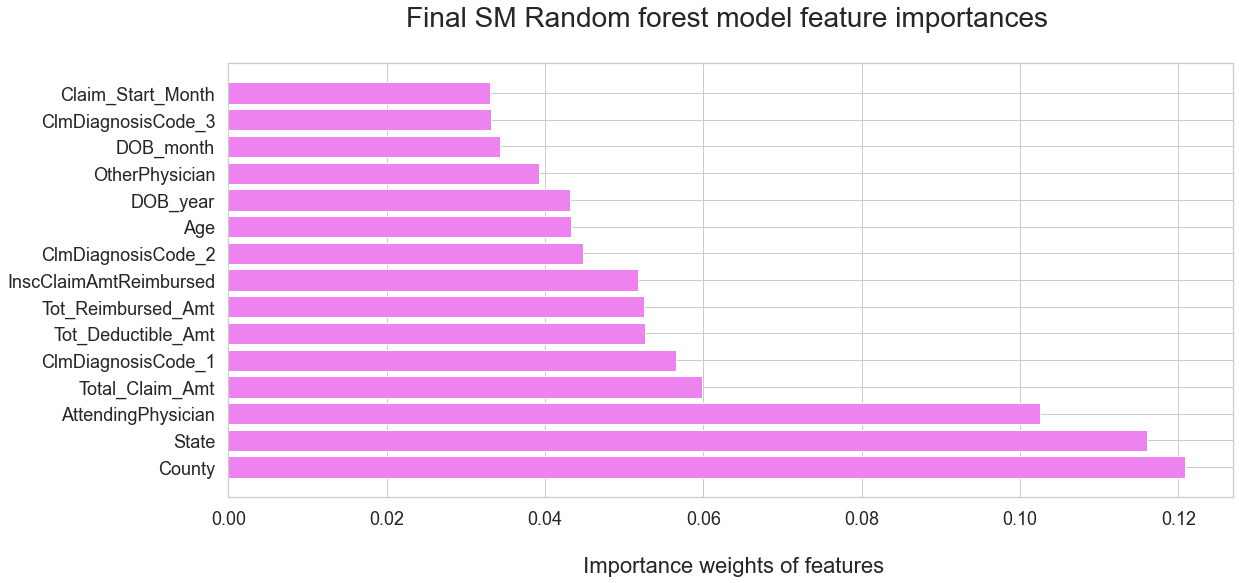

In [ ]:
# Creating feature importance table:

feature_imp_df1 = pd.DataFrame(zip(selected_feat1,\
                               abs(fin_rf1.feature_importances_)),
                               columns=["Feature Name", "Weight"])

feature_imp_df1 = feature_imp_df1.sort_values("Weight", ascending=False)\
                  .reset_index(drop=True)

# Looking at top 25 features

top_features1 = feature_imp_df1.head(20)

# Visualizing the results

plt.figure(figsize = (18,8))
plt.barh(top_features1["Feature Name"].head(15), top_features1["Weight"].head(15), color ="violet")
plt.xlabel("\n Importance weights of features", fontsize = 22)
plt.title("Final SM Random forest model feature importances \n", fontsize = 28)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.show()

In [ ]:
# Model using RFE 20 features

selected_feat2 = trainX_BSM.columns[rfe2.support_]

model_results(trainX_BSM[selected_feat2], trainY_BSM, testX_BSM[selected_feat2], testY_BSM, fin_rf2, show=True)

The Model Results for  RandomForestClassifier(max_depth=35, min_samples_leaf=3, min_samples_split=6,
                       n_estimators=125, oob_score=True, random_state=42)
************************************************************
Train Accuracy is equal to 0.987
Test Accuracy is equal to 0.760
The Precision score is 0.786
The Average Precision score is 0.704
The Recall score is 0.713
The F1 score is 0.748
The AUC/ROC score is 0.760
True-Positive: 73853.000
True-Negative: 83573.000
False-Positive: 20052.000
False-Negative: 29772.000
Correctly Classified: 157426.000
Incorrectly Classified: 49824.000


[0.9868274122172133,
 0.7595946924004825,
 0.7864650444598265,
 0.7126948130277443]

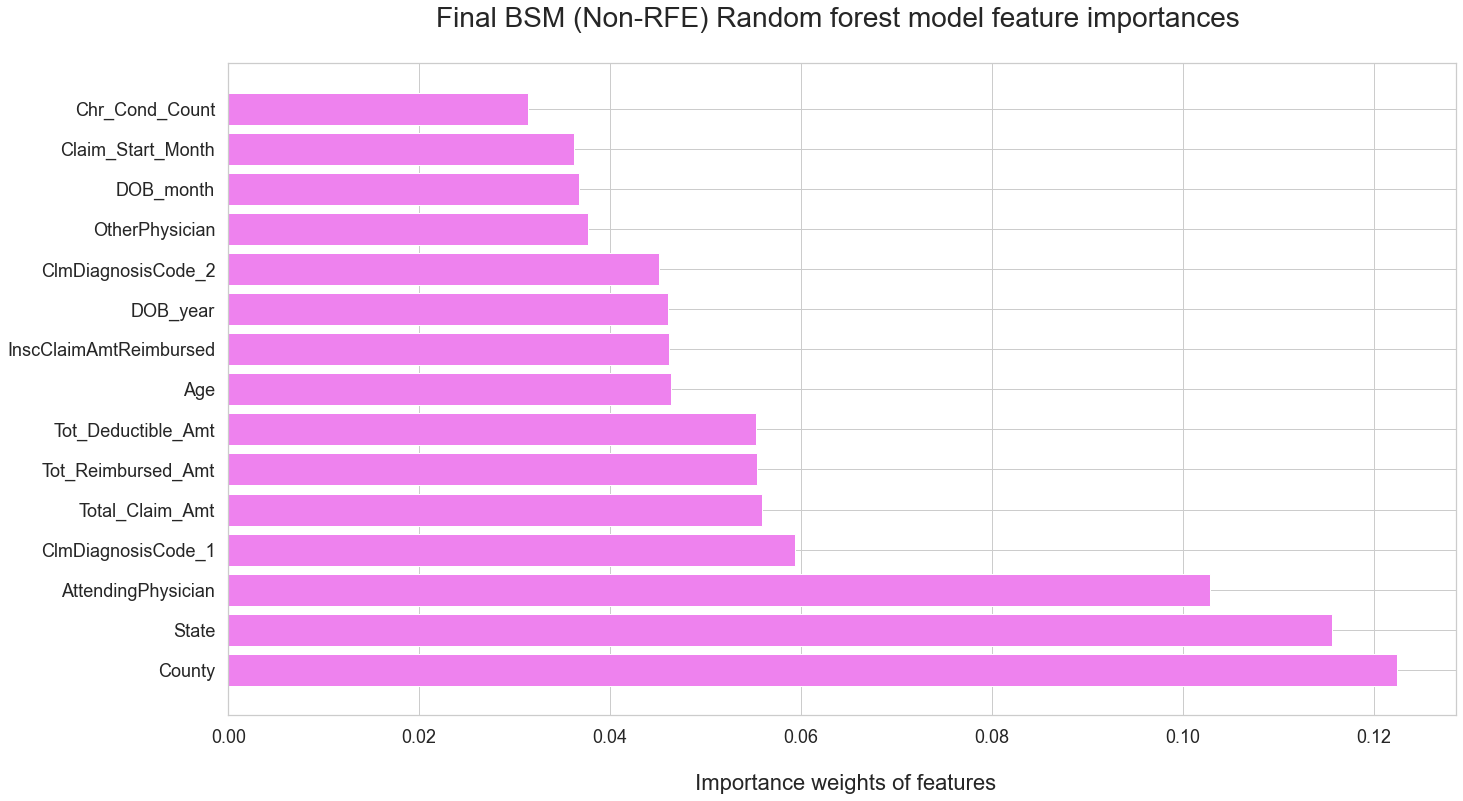

In [ ]:
# Creating feature importance table:

feature_imp_df2 = pd.DataFrame(zip(selected_feat2,\
                               abs(fin_rf2.feature_importances_)),
                               columns=["Feature Name", "Weight"])

feature_imp_df2 = feature_imp_df2.sort_values("Weight", ascending=False)\
                  .reset_index(drop=True)

# Looking at top 25 features

top_features2 = feature_imp_df2.head(20)

# Visualizing the results

plt.figure(figsize = (22,12))
plt.barh(top_features2["Feature Name"].head(15), top_features2["Weight"].head(15), color ="violet")
plt.xlabel("\n Importance weights of features", fontsize = 22)
plt.title("Final BSM (Non-RFE) Random forest model feature importances \n", fontsize = 28)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.show()

### # Visualizing a single tree for both models:

In [ ]:
# forest_tree_data1 = tree.export_graphviz(fin_rf1.estimators_[0],
#                      out_file=None, rounded=True, feature_names = selected_feat1,
#                      filled = True)

# graph1 = gv.Source(forest_tree_data1)
# display(SVG(graph1.pipe(format='svg')))

In [ ]:
# forest_tree_data2 = tree.export_graphviz(fin_rf2.estimators_[0],
#                      out_file=None, rounded=True, feature_names = selected_feat2,
#                      filled = True)

# graph2 = gv.Source(forest_tree_data2)
# display(SVG(graph2.pipe(format='svg')))

### # Full set of evaluation metrics for both models:

- Confusion matrix:

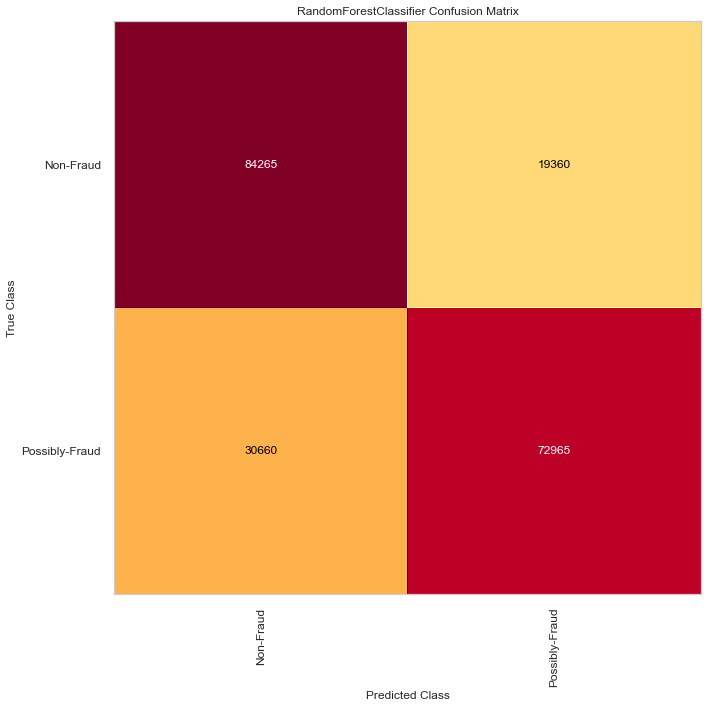

<AxesSubplot:title={'center':'RandomForestClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
# Visualizing the confusion matrix with Yellowbricks (thres=0.5)

plt.figure(figsize = (10,10))
visualizer = confusion_matrix(
    fin_rf1,
    trainX_SM[selected_feat1], trainY_SM, testX_SM[selected_feat1], testY_SM,
    classes=['Non-Fraud', 'Possibly-Fraud'])

visualizer.show()

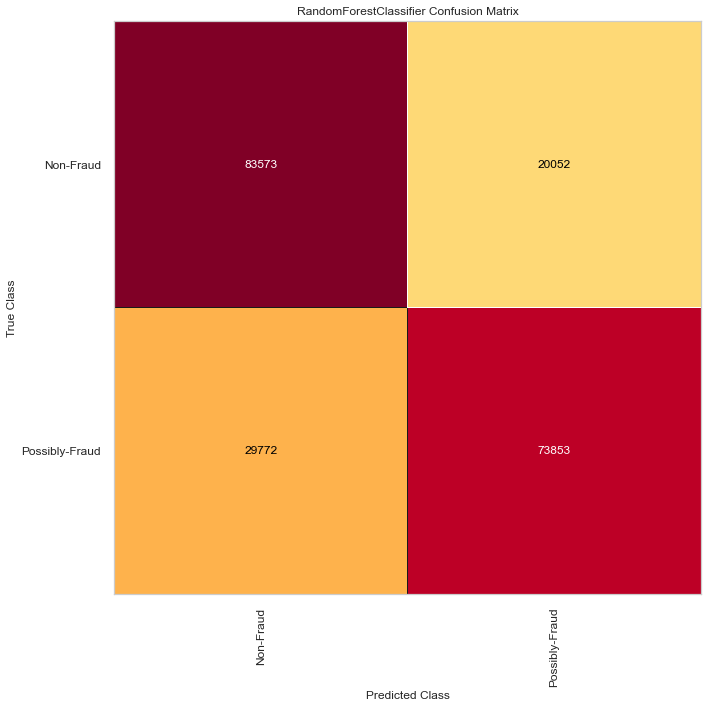

<AxesSubplot:title={'center':'RandomForestClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
# Visualizing the confusion matrix with Yellowbricks (thres=0.5)

plt.figure(figsize = (10,10))
visualizer = confusion_matrix(
    fin_rf2,
    trainX_BSM[selected_feat2], trainY_BSM, testX_BSM[selected_feat2], testY_BSM,
    classes=['Non-Fraud', 'Possibly-Fraud'])

visualizer.show()

- AUC/ROC curve

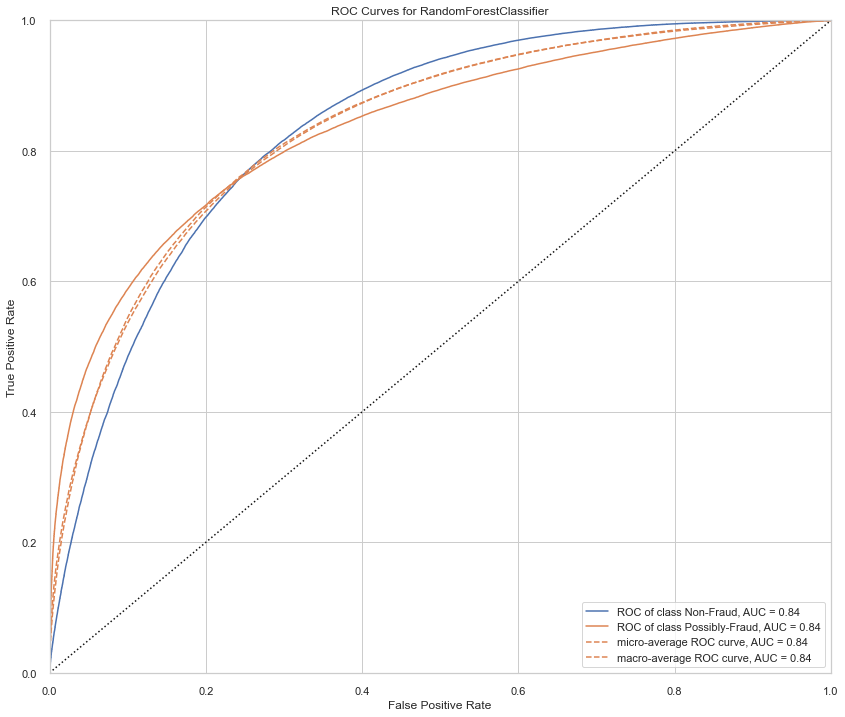

<AxesSubplot:title={'center':'ROC Curves for RandomForestClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
# Visualizing the AUC/ROC curve with Yellowbricks

plt.figure(figsize = (14,12))
sns.set_style("whitegrid")

visualizer = ROCAUC(fin_rf1, classes=['Non-Fraud', 'Possibly-Fraud'])

visualizer.fit(trainX_SM[selected_feat1], trainY_SM)        # Fit the training data to the visualizer
visualizer.score(testX_SM[selected_feat1], testY_SM)        # Evaluate the model on the test data

visualizer.show()

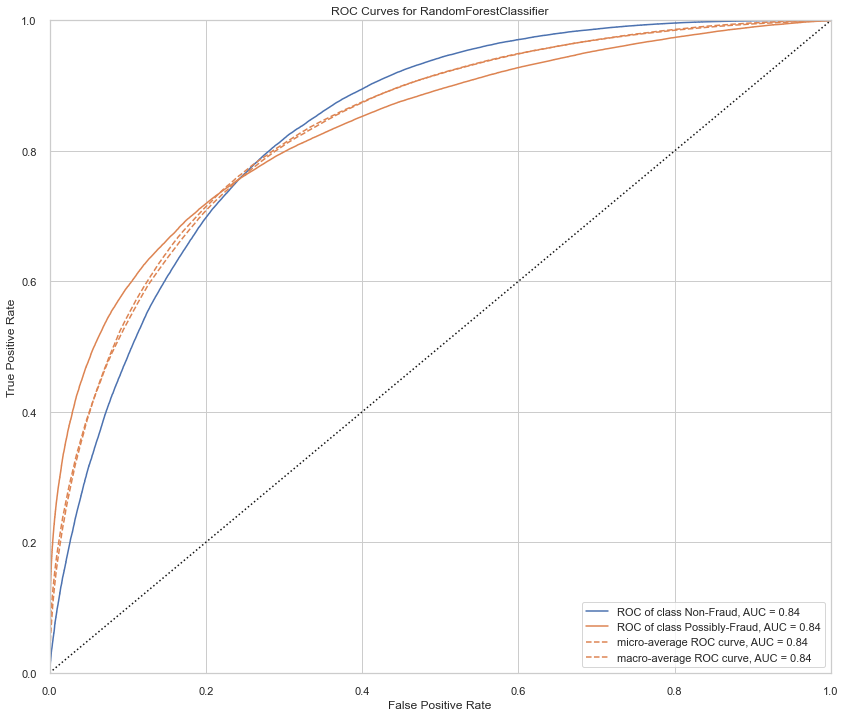

<AxesSubplot:title={'center':'ROC Curves for RandomForestClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
# Visualizing the AUC/ROC curve with Yellowbricks

plt.figure(figsize = (14,12))
sns.set_style("whitegrid")

visualizer = ROCAUC(fin_rf2, classes=['Non-Fraud', 'Possibly-Fraud'])

visualizer.fit(trainX_BSM[selected_feat2], trainY_BSM)        # Fit the training data to the visualizer
visualizer.score(testX_BSM[selected_feat2], testY_BSM)        # Evaluate the model on the test data

visualizer.show()

- Classification report

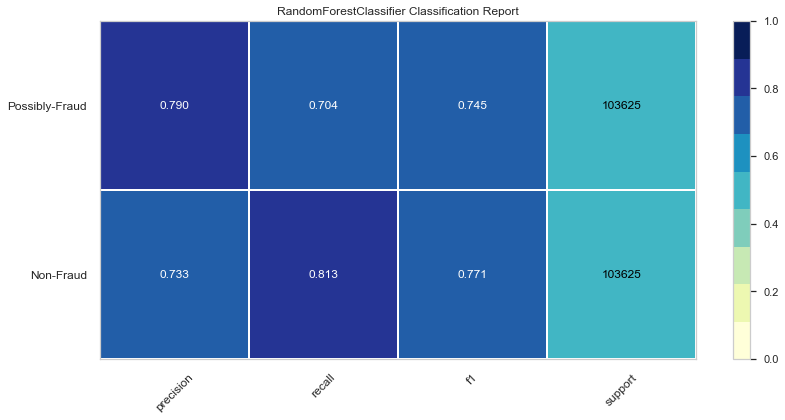

<AxesSubplot:title={'center':'RandomForestClassifier Classification Report'}>

In [ ]:
# Visualizing the classification report with Yellowbricks

plt.figure(figsize = (12,6))
sns.set_style("whitegrid")

visualizer = classification_report(
    fin_rf1,
    trainX_SM[selected_feat1], trainY_SM, testX_SM[selected_feat1], testY_SM,
    classes=['Non-Fraud', 'Possibly-Fraud'],
    cmap='YlGnBu',
    support=True)

visualizer.show()

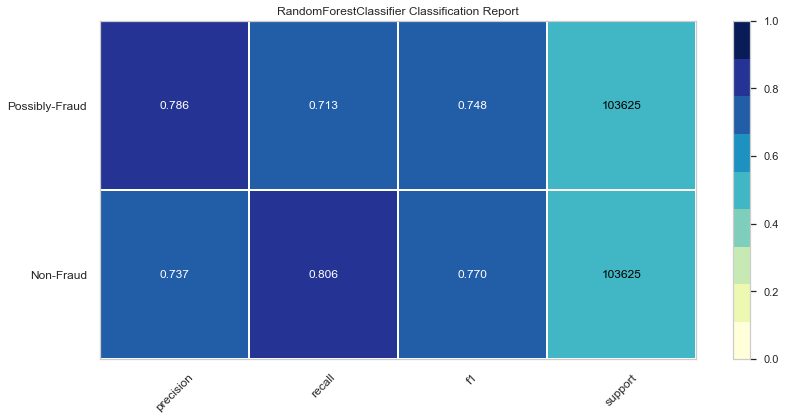

<AxesSubplot:title={'center':'RandomForestClassifier Classification Report'}>

In [ ]:
# Visualizing the classification report with Yellowbricks

plt.figure(figsize = (12,6))
sns.set_style("whitegrid")

visualizer = classification_report(
    fin_rf2,
    trainX_BSM[selected_feat2], trainY_BSM, testX_BSM[selected_feat2], testY_BSM,
    classes=['Non-Fraud', 'Possibly-Fraud'],
    cmap='YlGnBu',
    support=True)

visualizer.show()

- Precision-recall curve

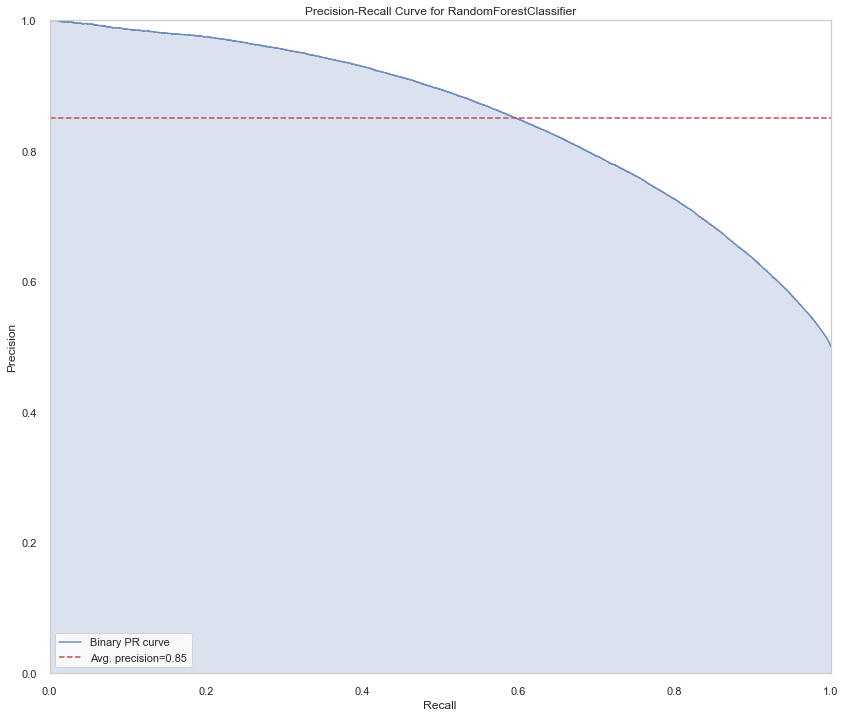

<AxesSubplot:title={'center':'Precision-Recall Curve for RandomForestClassifier'}, xlabel='Recall', ylabel='Precision'>

In [ ]:
# Visualizing precision-recall curve

from yellowbrick.classifier import precision_recall_curve

plt.figure(figsize = (14,12))
sns.set_style("whitegrid")
viz = precision_recall_curve(fin_rf1, trainX_SM[selected_feat1], trainY_SM, testX_SM[selected_feat1], testY_SM)
viz.show()

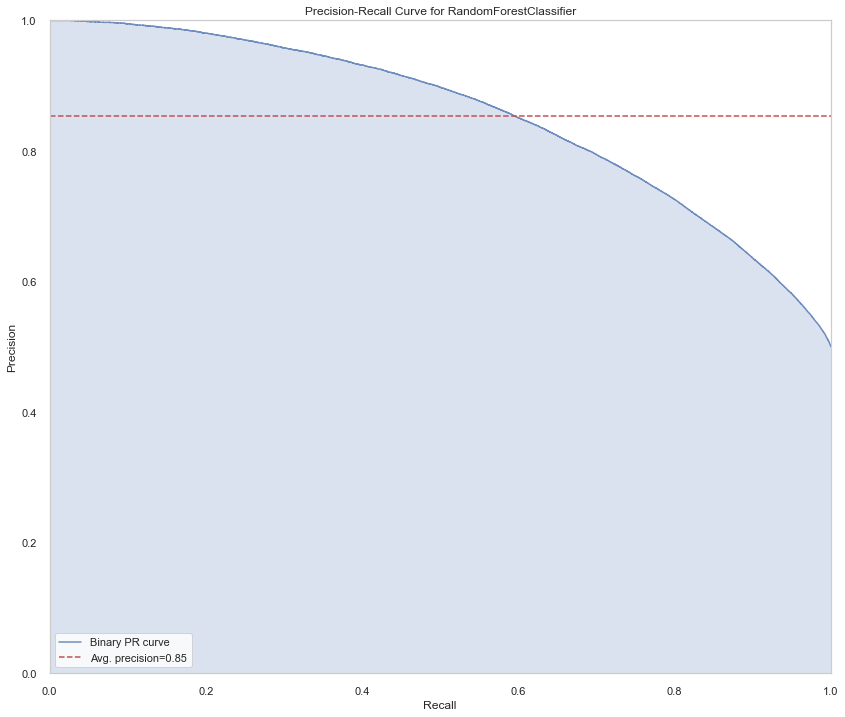

<AxesSubplot:title={'center':'Precision-Recall Curve for RandomForestClassifier'}, xlabel='Recall', ylabel='Precision'>

In [ ]:
# Visualizing precision-recall curve

from yellowbrick.classifier import precision_recall_curve

plt.figure(figsize = (14,12))
sns.set_style("whitegrid")
viz = precision_recall_curve(fin_rf2, trainX_BSM[selected_feat2], trainY_BSM, testX_BSM[selected_feat2], testY_BSM)
viz.show()

- Prediction error

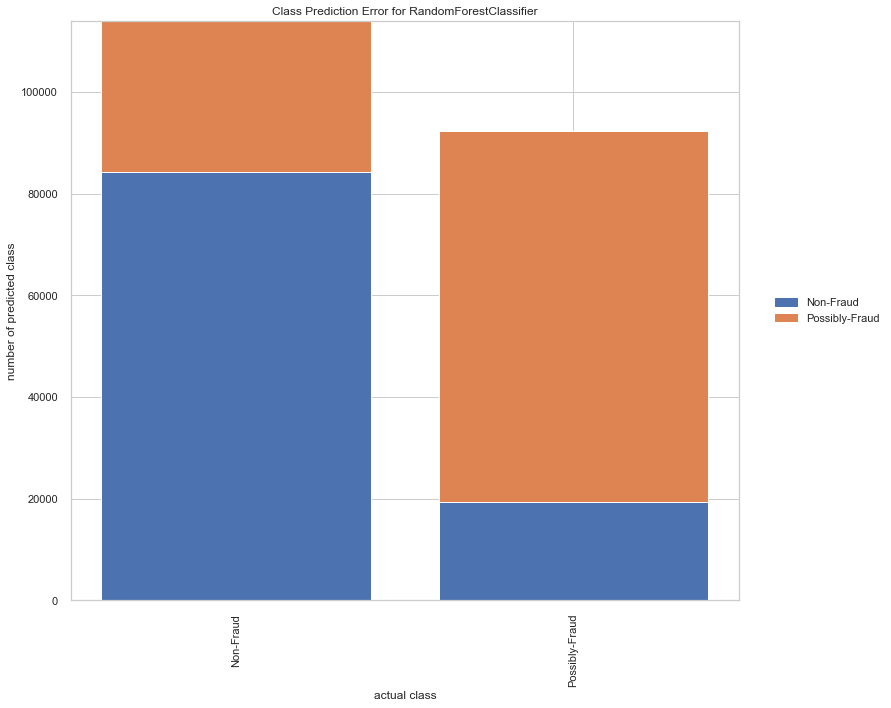

<AxesSubplot:title={'center':'Class Prediction Error for RandomForestClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [ ]:
# Visualizing prediction error

from yellowbrick.classifier import class_prediction_error

plt.figure(figsize = (14,10))
sns.set_style("whitegrid")
viz = class_prediction_error(
    fin_rf1,
    trainX_SM[selected_feat1], trainY_SM.values.ravel(),
    testX_SM[selected_feat1], testY_SM.values.ravel(),
    classes=['Non-Fraud', 'Possibly-Fraud'])

viz.show()

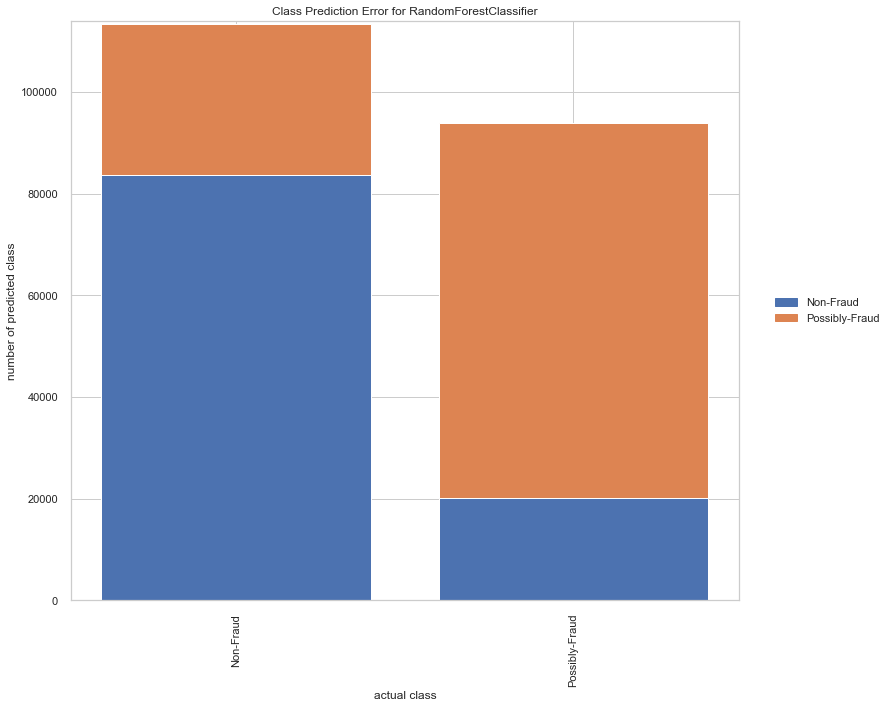

<AxesSubplot:title={'center':'Class Prediction Error for RandomForestClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [ ]:
# Visualizing prediction error

from yellowbrick.classifier import class_prediction_error

plt.figure(figsize = (14,10))
sns.set_style("whitegrid")
viz = class_prediction_error(
    fin_rf2,
    trainX_BSM[selected_feat2], trainY_BSM.values.ravel(),
    testX_BSM[selected_feat2], testY_BSM.values.ravel(),
    classes=['Non-Fraud', 'Possibly-Fraud'])

viz.show()

### # Threshold selection for both:

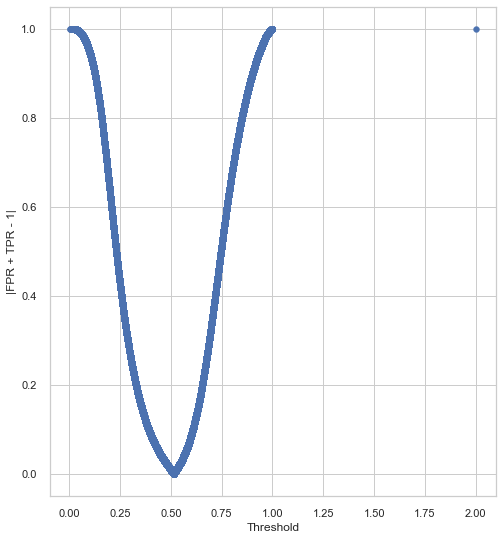

In [ ]:
# Visualizing the threshold

from sklearn.metrics import roc_curve

sns.set_style("whitegrid")
fpr1, tpr1, thresholds1 = roc_curve(trainY_SM,fin_rf1.predict_proba(trainX_SM[selected_feat1])[:,1],drop_intermediate=False)

plt.figure(figsize = (8,9))
plt.scatter(thresholds1,np.abs(fpr1+tpr1-1),linewidths=0.3)
plt.xlabel("Threshold")
plt.ylabel("|FPR + TPR - 1|")
plt.show()

In [ ]:
thresholds1[np.argmin(np.abs(fpr1+tpr1-1))]

0.5134077187367916

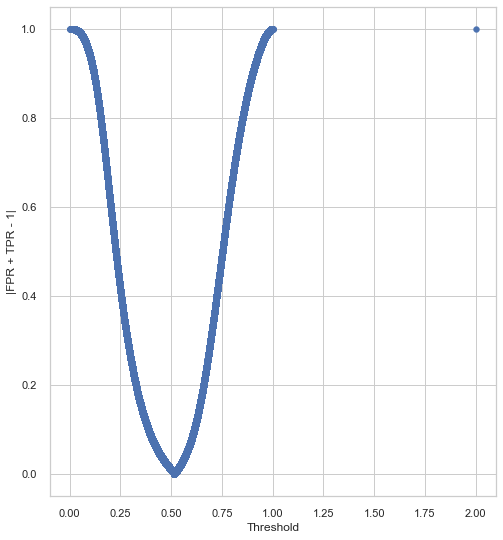

In [ ]:
# Visualizing the threshold

sns.set_style("whitegrid")
fpr2, tpr2, thresholds2 = roc_curve(trainY_BSM,fin_rf2.predict_proba(trainX_BSM[selected_feat2])[:,1],drop_intermediate=False)

plt.figure(figsize = (8,9))
plt.scatter(thresholds2,np.abs(fpr2+tpr2-1),linewidths=0.3)
plt.xlabel("Threshold")
plt.ylabel("|FPR + TPR - 1|")
plt.show()

In [ ]:
thresholds2[np.argmin(np.abs(fpr2+tpr2-1))]

0.5162350945857795

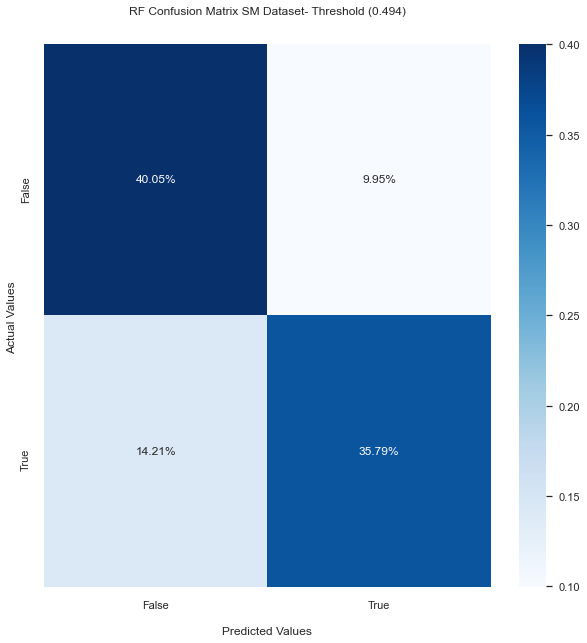

In [ ]:
# Looking at confusion matrix (thres=0.494)

cm1 = get_confusion_matrix(fin_rf1, testX_SM[selected_feat1], testY_SM, thres=0.494)

#Plotting the confusion matrix

labels = ['Non-Fraud', 'Possibly-Fraud']

plt.figure(figsize = (10,10))

ax = sns.heatmap(cm1/np.sum(cm1), annot=True, fmt='.2%', cmap='Blues')

ax.set_title('RF Confusion Matrix SM Dataset- Threshold (0.494)\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

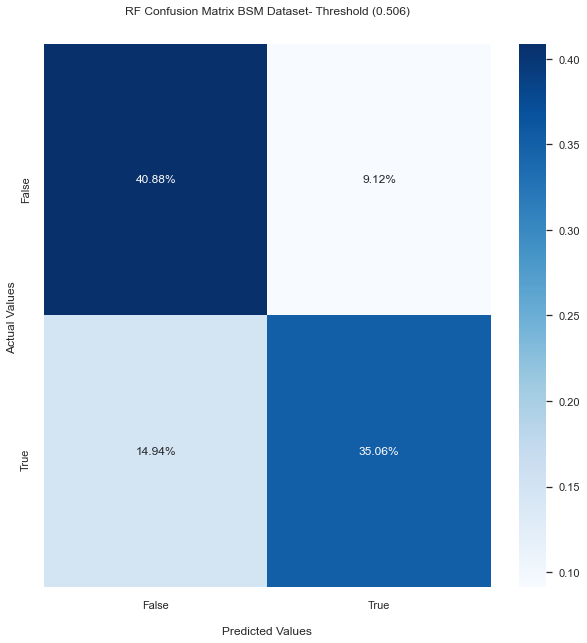

In [ ]:
# Looking at confusion matrix (thres=0.506)

cm2 = get_confusion_matrix(fin_rf2, testX_BSM[selected_feat2], testY_BSM, thres=0.506)

#Plotting the confusion matrix

labels = ['Non-Fraud', 'Possibly-Fraud']

plt.figure(figsize = (10,10))

ax = sns.heatmap(cm2/np.sum(cm2), annot=True, fmt='.2%', cmap='Blues')

ax.set_title('RF Confusion Matrix BSM Dataset- Threshold (0.506)\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

### # Summary Plot

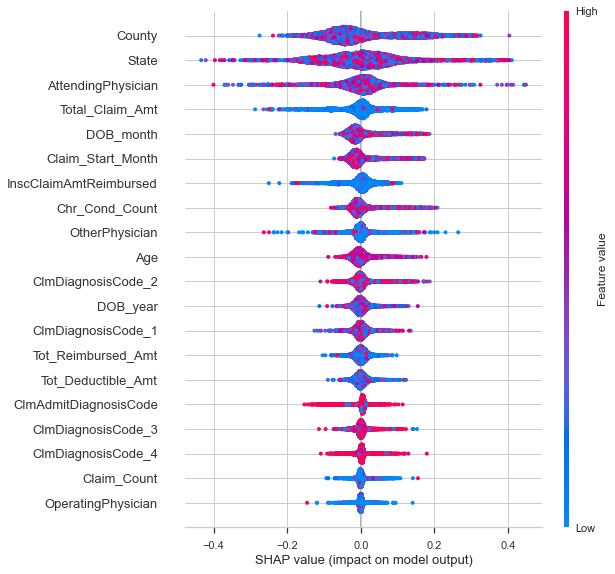

In [ ]:
shap.summary_plot(SMshap_values[0], testX_SM[selected_feat1].iloc[:10000,:])

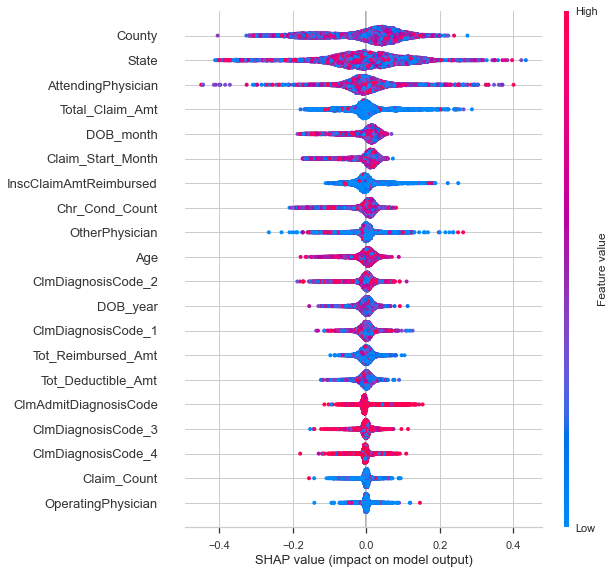

In [ ]:
shap.summary_plot(SMshap_values[1], testX_SM[selected_feat1].iloc[:10000,:])

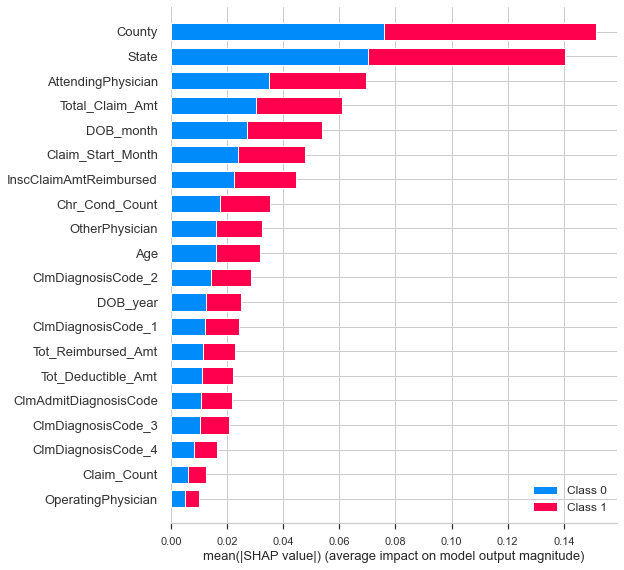

In [ ]:
shap.summary_plot(SMshap_values, testX_SM[selected_feat1].iloc[:10000,:])

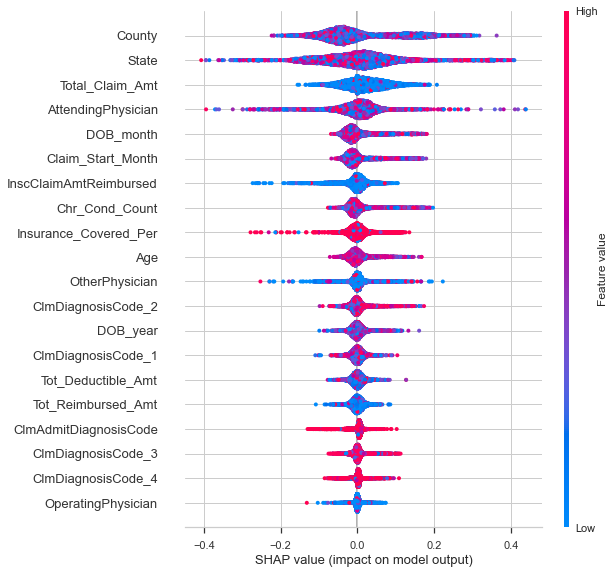

In [ ]:
shap.summary_plot(BSMshap_values[0], testX_BSM[selected_feat2].iloc[:10000,:])

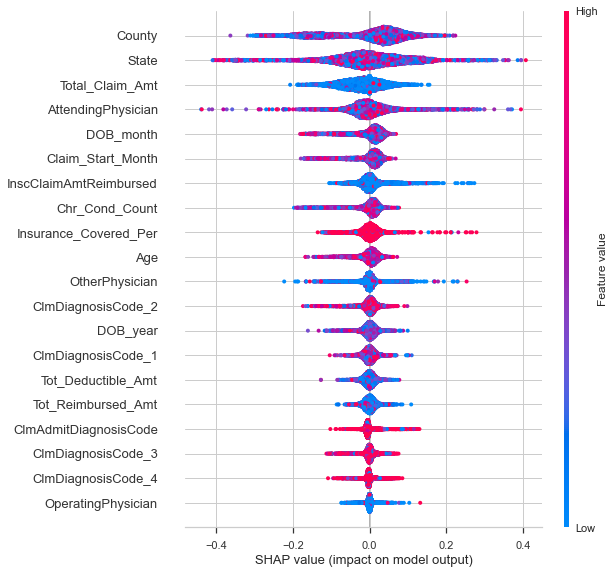

In [ ]:
shap.summary_plot(BSMshap_values[1], testX_BSM[selected_feat2].iloc[:10000,:])

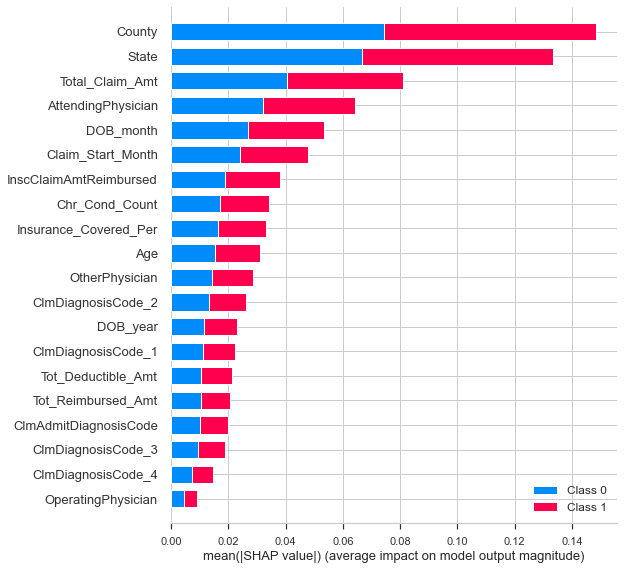

In [ ]:
shap.summary_plot(BSMshap_values, testX_BSM[selected_feat2].iloc[:10000,:])